# Overlevingsanalyse van tijd-tot-uitval van een studentencohort

## Managementsamenvatting

**Context.** Een afdeling institutioneel onderzoek van een vierjarige hogeschool wil begrijpen *wanneer*, niet alleen *of*, studenten vertrekken. Een instromend cohort wordt semester na semester gevolgd vanaf inschrijving; sommigen studeren af, sommigen vallen uit, en een enkeling is nog ingeschreven wanneer het waarnemingsvenster sluit. Omdat de uitkomst voor nog ingeschreven studenten onbekend is (rechts-gecensureerd), en omdat afstuderen een student uit de risicopopulatie haalt zonder een uitval te zijn, gooit gewone slagen/zakken-regressie de timinginformatie weg en vertekent elke schatting die censurering negeert. Het juiste instrument is **tijd-tot-gebeurtenis- (overlevings)analyse**, waarbij de gebeurtenis van belang **uitval** is en de klok wordt gemeten in ingeschreven academische semesters.

**Bedrijfsvraag.** Scheidt de **academische status in het eerste semester** van een student (een vroegwaarschuwingsvlag) de uitval-timingtrajecten van het cohort, en welke studentkenmerken drijven de uitvalhazard na correctie? De antwoorden voeden een vroegwaarschuwingssysteem: studenten met een hoog geschatte uitvalhazard zouden in hun eerste semesters begeleidingscontact moeten krijgen, wanneer interventie het goedkoopst en meest effectief is.

**Aanpak.** We simuleren inline een cohort van 100 studenten (geen externe gegevens) en werken vervolgens een standaard overlevingsworkflow af:

1. **PROC MEANS** profileert de voorspellers over de drie waargenomen uitkomsten (Afgestudeerd / Uitgevallen / nog Ingeschreven) om te bevestigen dat het gesimuleerde signaal zich zinnig gedraagt.
2. **PROC FREQ** kruist de academische status in het eerste semester tegen uitkomst met een chi-kwadraattoets van samenhang.
3. **PROC UNIVARIATE** rapporteert robuuste percentielen van tijd-tot-uitval per status.
4. **PROC LIFETEST** schat Kaplan-Meier-uitvalcurves gestratificeerd naar status en voert **log-rank**- en **Wilcoxon**-toetsen van gelijkheid uit.
5. **PROC PHREG** fit een multivariabel **Cox proportioneel-hazardmodel** voor de uitvalhazard, met een referentie-gecodeerd `CLASS`-effect, Efron-tie-afhandeling en risicolimietbetrouwbaarheidsintervallen.

**Wat de gegevens tonen.** Van de 100 gesimuleerde studenten zijn er **49 uitgevallen, 49 afgestudeerd en 2 nog ingeschreven** bij de afkap van 12 semesters. Studenten die in hun eerste semester een **academische waarschuwing** kregen (eerste-semester-GPA onder 2,5) vallen veel sneller uit dan studenten met goede status: mediane tijd-tot-uitval **3,8 semesters versus 8,7 semesters**, een scheiding die de log-rank-toets bevestigt (chi-kwadraat = 10,73, *p* = 0,0011). Het Cox-model identificeert eerste-semester-GPA (hazardratio 0,21 per GPA-punt, *p* < 0,0001), middelbareschool-GPA (HR 0,45, *p* = 0,027) en eerstegeneratiestatus (HR 2,03, *p* = 0,031) als significante gecorrigeerde drijvers van uitval, terwijl Pell-beursstatus niet significant is zodra GPA wordt gecontroleerd (HR 0,95, *p* = 0,85).

> *Alle cijfers zijn illustratief en gegenereerd uit synthetische gegevens; het zijn geen echte studentgegevens. Deze omgeving draait ongelicentieerd, dus het cohort is op 100 studenten gedimensioneerd.*

## Gegevensbronnen

Alle gegevens zijn **synthetisch**, inline gegenereerd in de eerste DATA-stap met `CALL STREAMINIT(20260611)` en de `RAND`-functie. Geen externe bestanden of netwerktoegang. Eén rij per gesimuleerde student.

**Dataset `inschrijvingen`** (100 rijen, één rij per student)

| Variabele | Type | Beschrijving | Genererende verdeling |
|----------|------|-------------|--------------------------|
| `student_id` | Num | Unieke studentsleutel | reeks 1–100 |
| `eerste_gen` / `eerste_gen_lbl` | Num / Char | Eerstegeneratievlag (0/1) en label | Bernoulli, ~42% |
| `pell` | Num | Pell-beurs- (financiële-behoefte)vlag (0/1) | Bernoulli, ~42% |
| `opleiding` | Char | STEM / BUS / HUM | categorisch (~42% / 32% / 26%) |
| `vo_gpa` | Num | Middelbareschool-GPA (1,8–4,0) | Normaal(3,00, 0,42), begrensd |
| `sem1_gpa` | Num | Eerste-semester-hogeschool-GPA (0–4,0) | f(vo_gpa, opleiding) + Normale ruis |
| `status` | Char | Academische status in het eerste semester | `sem1_gpa < 2.5` → Academische waarschuwing, anders Goede status |
| `tijd_sem` | Num | Ingeschreven semesters tot gebeurtenis of censurering | concurrerende Weibull-trekkingen; afgekapt bij 12 |
| `uitgevallen` | Num | Uitvalgebeurtenisindicator (1 = uitgevallen, 0 = gecensureerd) | afgeleid |
| `uitkomst` | Char | Afgestudeerd / Uitgevallen / Ingeschreven | afgeleid uit concurrerende trekkingen |

Een latente lineaire voorspeller op logschaal koppelt het **uitvaltempo** van elke student aan eerste-semester-GPA, middelbareschool-GPA, eerstegeneratiestatus en financiële behoefte, zodat de voorspellers een echt maar ruizig signaal dragen. Uitval en afstuderen worden getrokken als **concurrerende** latente tijden (Weibull); wat eerst optreedt binnen een venster van 12 semesters wordt de waargenomen uitkomst, en studenten die semester 12 bereiken zonder een van beide zijn rechts-gecensureerd. Voor de overlevingsmodellen is de **gebeurtenis uitval** (`uitgevallen = 1`); afstuderen en voortdurende inschrijving worden beide als censurering behandeld (`uitgevallen = 0`).

## 1. Simuleer het studentencohort

De eerste cel bouwt een synthetisch cohort van 100 studenten. Een latente lineaire voorspeller op logschaal bindt het uitvaltempo van elke student aan eerste-semester-GPA, middelbareschool-GPA, eerstegeneratiestatus en Pell-status. Uitval en afstuderen worden gegenereerd als **concurrerende** latente tijden (Weibull-trekkingen); wat eerst gebeurt binnen een waarnemingsvenster van 12 semesters wordt de waargenomen uitkomst, en studenten die semester 12 bereiken zonder uit te vallen of af te studeren zijn rechts-gecensureerd. Een eerste-semester-GPA onder 2,5 markeert de student voor een **academische waarschuwing** — het vroegwaarschuwingssignaal dat we toetsen in de overlevingsstap. Willekeurige trekkingen gebruiken `CALL STREAMINIT` voor reproduceerbaarheid en de `RAND`-functie over Uniform-, Normaal- en Weibull-verdelingen. Harde ondergrenzen en begrenzingen houden elke waarde plausibel (GPA's in 0–4,0).

In [1]:
GEGEVENS inschrijvingen;
    CALL streaminit(20260611);
    LENGTE status $24 eerste_gen_lbl $16 opleiding $4 uitkomst $12;
    DOE student_id = 1 TOT 100;
        /* Eerste-generatie- en financiele-behoefte-vlaggen */
        eerste_gen = (rand("uniform") < 0.42);
        ALS eerste_gen DAN eerste_gen_lbl = "Eerste-generatie";
        ANDERS              eerste_gen_lbl = "Niet-eerste-gen";
        pell = (rand("uniform") < 0.42);

        /* Studierichting */
        v = rand("uniform");
        ALS      v < 0.42 DAN opleiding = "STEM";
        ANDERS ALS v < 0.74 DAN opleiding = "BUS";
        ANDERS                  opleiding = "HUM";

        /* Academische voorbereiding en eerste-semesterprestatie */
        vo_gpa = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        sem1_gpa = round(MIN(4.0, MAX(0.0,
                     0.55*vo_gpa + 1.05 + 0.12*(opleiding="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Vroegwaarschuwingsvlag: eerste-semester-GPA onder 2,5 = academische waarschuwing */
        ALS sem1_gpa < 2.5 DAN status = "Academische waarschuwing";
        ANDERS                    status = "Goede status";

        /* Latente uitvalhazard op logschaal: lagere GPA, eerste-generatie
           en Pell-status verhogen het uitvaltempo. */
        eta = -1.05
             - 1.45*(sem1_gpa - 2.8)
             - 0.55*(vo_gpa - 3.0)
             + 1.05*eerste_gen
             + 0.45*pell;
        uitval_tempo = EXP(eta);

        /* Concurrerende latente tijden (semesters): uitval vs. afstuderen */
        t_uitval = rand("weibull", 1.2, 7.0) / MAX(0.30, uitval_tempo);
        t_afstuderen = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(sem1_gpa - 2.8));

        /* Administratief censureringsvenster van 12 semesters */
        censuur_bij = 12;
        ALS t_uitval <= t_afstuderen AND t_uitval <= censuur_bij DAN DOE;
            uitkomst = "Uitgevallen";   uitgevallen = 1; tijd_sem = t_uitval;
        EINDE;
        ANDERS ALS t_afstuderen < t_uitval AND t_afstuderen <= censuur_bij DAN DOE;
            uitkomst = "Afgestudeerd"; uitgevallen = 0; tijd_sem = t_afstuderen;
        EINDE;
        ANDERS DOE;
            uitkomst = "Ingeschreven";  uitgevallen = 0; tijd_sem = censuur_bij;
        EINDE;
        tijd_sem = round(tijd_sem, 0.1);
        UITVOER;
    EINDE;
    BEWAREN student_id eerste_gen eerste_gen_lbl pell opleiding vo_gpa
         sem1_gpa status tijd_sem uitgevallen uitkomst;
UITVOEREN;



NOTE: DATA inschrijvingen


NOTE: Wrote inschrijvingen (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Profileer voorspellers per waargenomen uitkomst

Voordat we modelleren, bevestigen we dat de gesimuleerde voorspellers in de verwachte richtingen bewegen. **PROC MEANS** rapporteert het aantal, gemiddelde, spreiding en bereik van elke numerieke voorspeller binnen de drie waargenomen uitkomsten.

Het cohort splitst in **49 Afgestudeerd / 49 Uitgevallen / 2 nog Ingeschreven**. Afgestudeerden dragen een hogere eerste-semester-GPA (gemiddelde **2,94** versus **2,54** voor uitgevallen studenten) en een hogere middelbareschool-GPA (**3,10** versus **2,90**) — precies de academische-voorbereidingsgradiënt die de analyse verwacht. De twee nog ingeschreven studenten zitten exact op het censureringsplafond van 12 semesters bij `tijd_sem` (gemiddelde 12,00, standaardafwijking 0), de rechts-censurering die een verloopanalyse moet respecteren. Onder uitgevallen studenten komt de gebeurtenis vroeg: gemiddelde **3,31 semesters**, variërend van 0,1 tot 8,9.

In [2]:
PROCEDURE GEMIDDELDEN GEGEVENS=inschrijvingen n mean std MIN MAX maxdec=2;
    KLASSE uitkomst;
    VARIABELE vo_gpa sem1_gpa tijd_sem;
    LABEL vo_gpa="Middelbareschool-GPA"
          sem1_gpa="Eerste-semester-GPA"
          tijd_sem="Tijd tot uitval (semesters)"
          uitkomst="Waargenomen uitkomst";
UITVOEREN;


                                                  The MEANS Procedure

                                    Analysis Variable : vo_gpa Middelbareschool-GPA

        Waargenomen uitkomst          N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------------
        Afgestudeerd                     49           3.10           0.46           1.97           4.00
        Ingeschreven                      2           3.10           0.17           2.98           3.22
        Uitgevallen                      49           2.90           0.45           2.01           3.89
        -----------------------------------------------------------------------------------------------

                                    Analysis Variable : sem1_gpa Eerste-semester-GPA

        Waargenomen uitkomst          N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Volgt de vroegwaarschuwingsvlag de uitkomst?

Het vroegwaarschuwingssysteem markeert elke student wiens eerste-semester-GPA onder 2,5 valt voor een **academische waarschuwing**. **PROC FREQ** kruist die vlag tegen de waargenomen uitkomst en voert een chi-kwadraattoets van samenhang uit. We onderdrukken rij-, kolom- en totaalpercentages (`NOROW NOCOL NOPERCENT`) zodat de tabel de ruwe aantallen toont, en voegen eenweg-frequenties van `status` en eerstegeneratiestatus toe voor de cohortsamenstelling.

De kruistabel is scherp: van de **29** studenten die voor een academische waarschuwing zijn gemarkeerd, zijn er **21 uitgevallen** en slechts 8 afgestudeerd; van de **71** met goede status zijn er **41 afgestudeerd** en 28 uitgevallen. De samenhang is significant (chi-kwadraat = 9,21, df = 2, *p* = 0,0100; Cramérs V = 0,30). Let op de **waarschuwing die ermee wordt afgedrukt**: met 100 studenten en een dunne "Ingeschreven"-kolom met twee afgestudeerden heeft een derde van de tabelcellen verwachte aantallen onder 5, dus de chi-kwadraat-*p*-waarde is hier fragiel. Die fragiliteit is precies waarom de overlevingstoetsen in de volgende secties — die de volledige timinginformatie gebruiken in plaats van een 3×2-tabel — de betrouwbaardere toets van het statuseffect zijn.

                                                   The FREQ Procedure

Table of Academische status by Waargenomen uitkomst

Academische status       |Afgestudeerd |Ingeschreven | Uitgevallen |        Total
-------------------------+-------------+-------------+-------------+-------------
Academische waarschuwing |           8 |           0 |          21 |           29
-------------------------+-------------+-------------+-------------+-------------
Goede status             |          41 |           2 |          28 |           71
-------------------------+-------------+-------------+-------------+-------------
Total                    |          49 |           2 |          49 |          100

Statistics for Table of Academische status by Waargenomen uitkomst

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likelihood Ratio Chi-Square               


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_status_uitkomst.spec.json
NOTE: ODS plot written: freq_status.spec.json
NOTE: ODS plot written: freq_eerste_gen_lbl.spec.json
NOTE: PROC FREQ statement used.


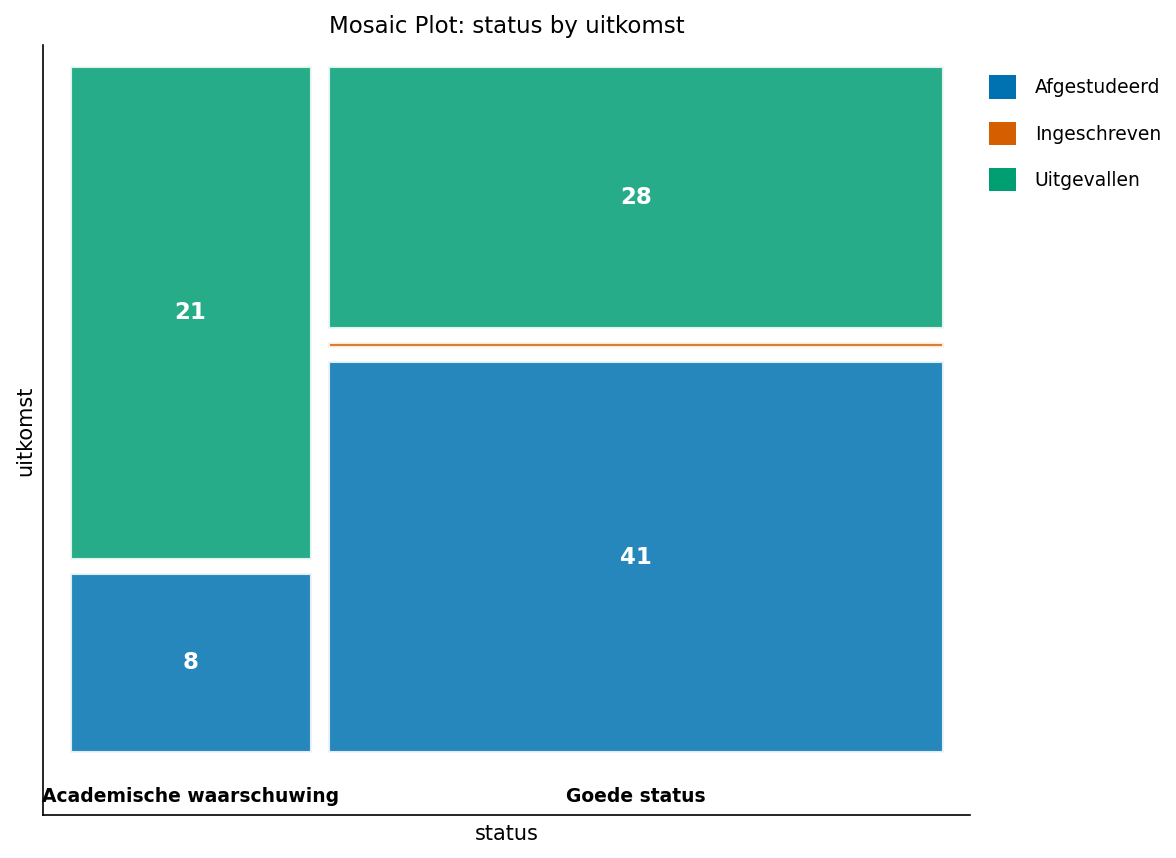

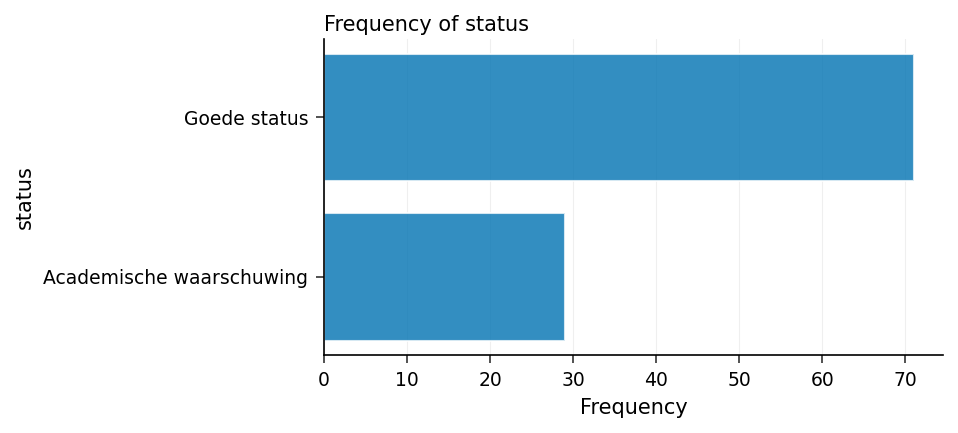

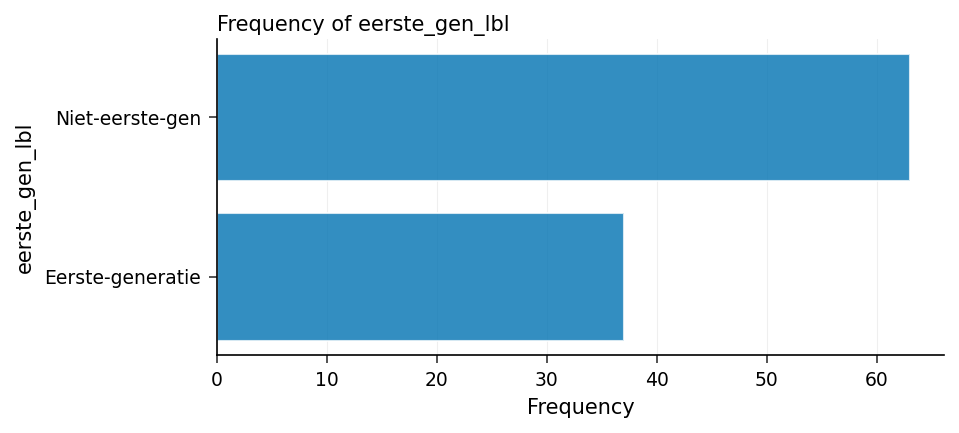

In [3]:
PROCEDURE FREQUENTIES GEGEVENS=inschrijvingen;
    TABLES status*uitkomst / chisq norow nocol nopercent;
    TABLES status eerste_gen_lbl;
    LABEL status="Academische status"
          uitkomst="Waargenomen uitkomst"
          eerste_gen_lbl="Generatiestatus";
UITVOEREN;


## 4. Wanneer treedt uitval op? Percentielen per status

Voor de studenten die daadwerkelijk uitvielen, *wanneer* vertrokken ze? **PROC UNIVARIATE** (beperkt tot `uitgevallen = 1`) rapporteert de 10e, 50e (mediaan) en 90e percentielen van tijd-tot-uitval binnen elke statusgroep, weggeschreven naar een uitvoerdataset die we vervolgens afdrukken. Dit beschrijft de spreiding van uitval-timing zonder een verdeling aan te nemen.

De mediane uitval onder studenten die vertrokken vindt plaats rond semester **2,4** (academische waarschuwing) versus **2,6** (goede status) — dichtbij, omdat *conditioneel op uitvallen* beide groepen doorgaans vroeg vertrekken. Het statuseffect gaat daarom niet vooral over *wanneer* een uitval gebeurt, maar over *hoeveel* studenten uitvallen en hoe snel de risicopopulatie dunner wordt, wat precies is wat de Kaplan-Meier-curves in de volgende sectie vastleggen.

In [4]:
PROCEDURE UNIVARIATE GEGEVENS=inschrijvingen NOPRINT;
    WAAR uitgevallen = 1;
    KLASSE status;
    VARIABELE tijd_sem;
    UITVOER out=uitval_ref pctlpts=10 50 90 pctlpre=t_ p=;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=uitval_ref noobs label;
    TITEL "Tijd-tot-uitval percentielen (semesters), naar academische status";
UITVOEREN;
TITEL;


                           Tijd-tot-uitval percentielen (semesters), naar academische status                            

                  STATUS  T_10  T_50  T_90
Academische waarschuwing   0.2   2.4   7.9
Goede status               0.4   2.6   8.7




NOTE: PROC UNIVARIATE
NOTE: Output dataset uitval_ref has 2 observations and 4 variables.
NOTE: PROC PRINT data=uitval_ref

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Kaplan-Meier-uitvalcurves per academische status

Nu de kern-overlevingsstap. **PROC LIFETEST** schat de niet-parametrische **Kaplan-Meier**-overlevingsfunctie voor *tijd tot uitval*, waarbij afstuderen en voortdurende inschrijving als censurering worden behandeld (`uitgevallen(0)` markeert de gecensureerde waarnemingen). Stratificeren naar `status` produceert één uitvalcurve per groep, en `TEST=(LOGRANK WILCOXON)` voert twee complementaire toetsen uit van de vraag of die curves verschillen: de **log-rank**-toets weegt alle gebeurtenistijden gelijk (gevoelig voor late verschillen), terwijl de **Wilcoxon**-toets vroege gebeurtenistijden zwaarder weegt (gevoelig voor vroeg verloop). `PLOTS=SURVIVAL` vraagt de overlappende overlevingscurve-grafiek.

Over het cohort zijn er **49 uitvalgebeurtenissen en 51 gecensureerde** waarnemingen. De curves scheiden duidelijk: studenten met een academische waarschuwing bereiken een **mediane overleving (tijd-tot-uitval) van 3,8 semesters**, terwijl studenten met goede status meer dan twee keer zo lang meegaan (**8,7 semesters**). Beide toetsen verwerpen gelijkheid — **log-rank chi-kwadraat = 10,73, *p* = 0,0011; Wilcoxon chi-kwadraat = 7,66, *p* = 0,0056** — en de vergelijkbare statistieken vertellen ons dat de kloof over het volledige inschrijvingsvenster aanhoudt, niet slechts een vroege piek is. De plot maakt de boodschap onmiddellijk: de oranje academische-waarschuwingscurve daalt steil door de eerste vier semesters, terwijl de blauwe goede-statuscurve hoog blijft.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: status = Academische waarschuwing

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000    0.7556     0.0804        


NOTE: PROC LIFETEST data=inschrijvingen

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


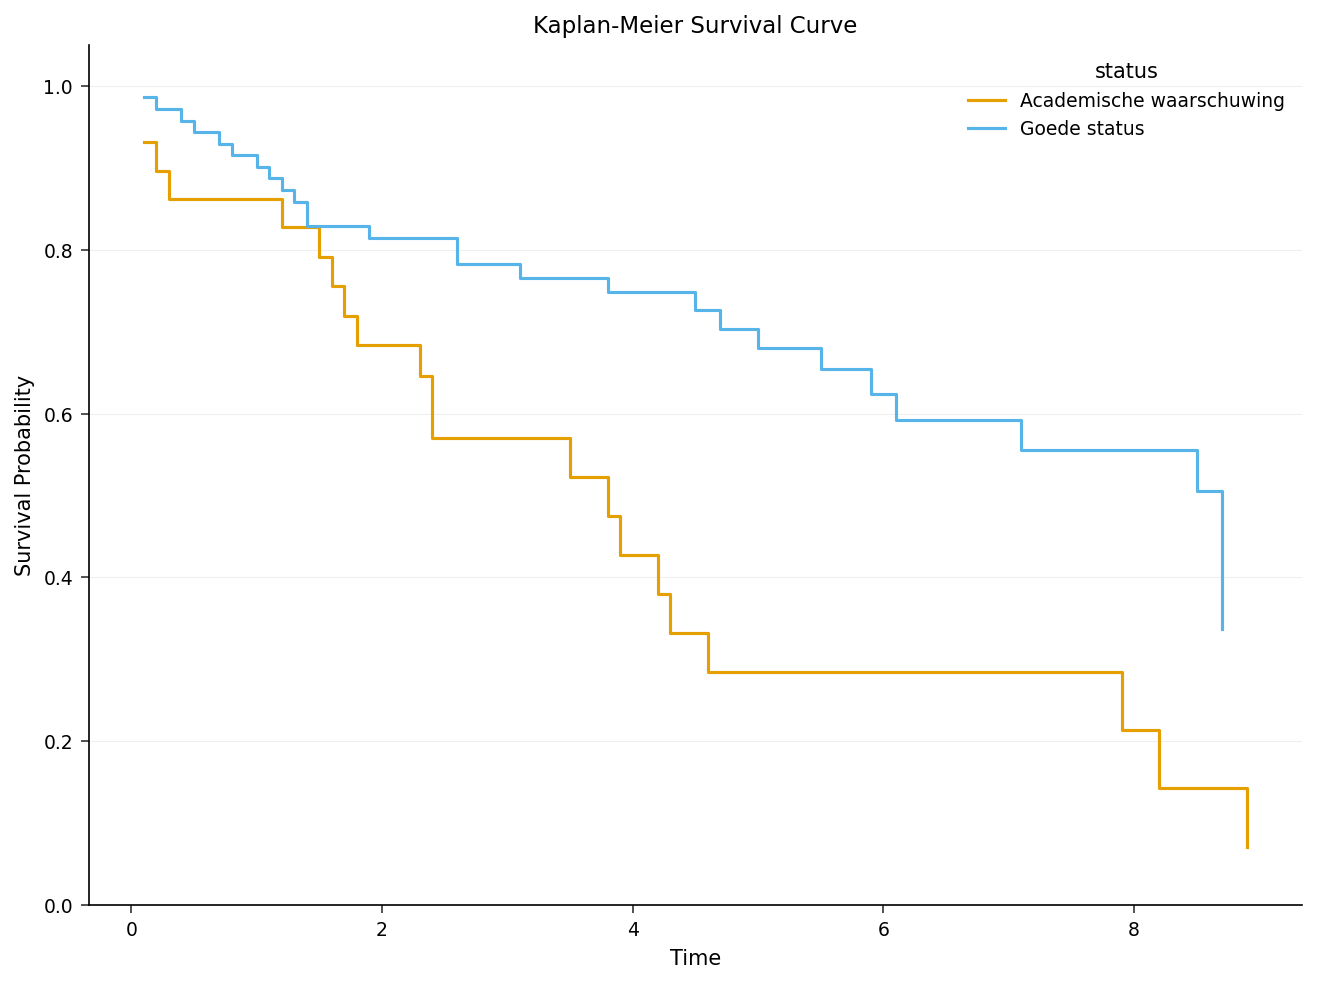

In [5]:
PROCEDURE LIFETEST GEGEVENS=inschrijvingen PLOTS=SURVIVAL METHOD=km;
    TIME tijd_sem*uitgevallen(0);
    STRATA status / TEST=(logrank WILCOXON);
UITVOEREN;


## 6. Multivariabel Cox proportioneel-hazardmodel voor uitval

**PROC PHREG** fit het **Cox proportioneel-hazardmodel** voor de uitvalhazard, waarbij de voorspellers gelijktijdig worden gecorrigeerd. Belangrijkste verzoeken:

- `uitgevallen(0)` maakt **uitval** de gebeurtenis en al het andere gecensureerd.
- `CLASS eerste_gen_lbl (ref="Niet-eerste-gen") / param=ref` codeert de eerstegeneratiefactor referentiegewijs, zodat de hazardratio wordt afgelezen tegen studenten van niet-eerstegeneratie.
- `TIES=EFRON` is de aanbevolen tie-afhandelingsbenadering wanneer meerdere studenten in hetzelfde semester vertrekken.
- `RL` voegt hazardratio- (risicolimiet)betrouwbaarheidsintervallen toe.
- De `HAZARDRATIO`-instructie rapporteert het eerstegeneratiecontrast tegen de referentiegroep.

Een hazardratio boven 1 betekent *snellere* uitval (hoger risico); onder 1 betekent *tragere* uitval (beschermend).

In [6]:
PROCEDURE PHREG GEGEVENS=inschrijvingen;
    KLASSE eerste_gen_lbl (REF="Niet-eerste-gen") / PARAM=REF;
    MODEL tijd_sem*uitgevallen(0) = vo_gpa sem1_gpa eerste_gen_lbl pell
          / TIES=efron rl;
    hazardratio "Eerste-generatie vs. niet-eerste-gen" eerste_gen_lbl / DIFF=REF;
    LABEL vo_gpa="Middelbareschool-GPA"
          sem1_gpa="Eerste-semester-GPA"
          eerste_gen_lbl="Generatiestatus"
          pell="Pell-status";
UITVOEREN;


        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                              Analysis of Maximum Likelihood Estimates                                               

Parameter                              DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
-------------------------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------


NOTE: PROC PHREG data=inschrijvingen

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. Interpretatie en vervolgstappen

**De uitvoer van begin tot eind lezen:**

- **PROC MEANS** bevestigt het gesimuleerde signaal: studenten die afstudeerden dragen een hogere eerste-semester-GPA (2,94 versus 2,54) en middelbareschool-GPA (3,10 versus 2,90) dan uitgevallen studenten, en de nog ingeschreven studenten zitten op het plafond van 12 semesters — de rechts-censurering die de overlevingsmodellen respecteren.
- **PROC FREQ** toont dat de academische-waarschuwingsvlag in het eerste semester de uitkomst volgt (21 van de 29 gemarkeerde studenten vielen uit; 41 van de 71 goede-statusstudenten studeerden af; *p* = 0,0100), terwijl eerlijk wordt aangegeven dat de chi-kwadraat fragiel is in een tabel van 100 studenten met dunne cellen.
- **PROC UNIVARIATE** toont dat *conditioneel op uitvallen* beide groepen vroeg vertrekken (mediaan ~2,4–2,6 semesters); het statuseffect gaat over hoeveel studenten uitvallen en hoe snel de risicopopulatie dunner wordt, niet over de timing onder degenen die vertrekken.
- **PROC LIFETEST** levert de kernboodschap: Kaplan-Meier-uitvalcurves die scherp scheiden per status (mediaan 3,8 versus 8,7 semesters; log-rank *p* = 0,0011, Wilcoxon *p* = 0,0056). De vroegwaarschuwingsvlag is een echte, statistisch onderbouwde discriminator van uitval-timing.
- **PROC PHREG** kwantificeert het gecorrigeerde effect van elke voorspeller op de uitvalhazard. Na correctie is de **eerste-semester-GPA de sterkste beschermende factor** (hazardratio 0,21 per GPA-punt, 95% BI 0,10–0,44, *p* < 0,0001): elk extra GPA-punt snijdt de uitvalhazard met ongeveer vier vijfde. **Middelbareschool-GPA** is ook beschermend (HR 0,45, 95% BI 0,22–0,91, *p* = 0,027). **Eerstegeneratiestudenten** lopen ongeveer het dubbele van de uitvalhazard van niet-eerstegeneratie-leeftijdgenoten met dezelfde GPA's (HR 2,03, 95% BI 1,07–3,84, *p* = 0,031). **Pell-status is niet significant** zodra GPA wordt gecontroleerd (HR 0,95, 95% BI 0,53–1,69, *p* = 0,85) — een nuttige herinnering dat een ruwe risicofactor kan wegvallen na correctie. De globale nulhypothese wordt beslissend verworpen (likelihood-ratio chi-kwadraat = 31,11 op 4 df, *p* < 0,0001).

**Hoe een instelling hierop zou handelen.** Het Cox-model produceert een lineaire voorspeller per student (risicoscore) die het cohort rangschikt naar uitvalhazard; de hoogste-risicostudenten — lage eerste-semester-GPA gecombineerd met eerstegeneratiestatus — worden in hun eerste semesters naar vroegwaarschuwingsbegeleiding geleid, wanneer interventie het goedkoopst en meest effectief is. De Kaplan-Meier-vergelijking geeft begeleiders één enkel, verdedigbaar criterium dat ze al aan het einde van semester één verzamelen: academische status.

**Kanttekeningen en uitbreidingen.** (1) Dit synthetische cohort behandelt afstuderen als censurering voor het uitvalmodel; met echte gegevens zijn afstuderen en uitval echte **concurrerende risico's**, en een concurrerende-risico's- (cumulatieve-incidentie)uitbreiding via PROC PHREG `EVENTCODE=` zou het overschatten van de uitvalkans vermijden. (2) De proportioneel-hazardaanname zou gecontroleerd moeten worden (PHREG `ASSESS PH` of Schoenfeld-residuen) voordat men één hazardratio over alle semesters vertrouwt. (3) Tijdsvariërende covariaten — semester-per-semester-GPA, wijzigingen in studiefinanciering, studielast — komen veel voor in retentiegegevens en worden vanzelfsprekend afgehandeld door PHREG-programmeerinstructies. (4) Het cohort van 100 studenten hier is gedimensioneerd op de ongelicentieerde runlimiet; een productieanalyse zou enkele duizenden studenten dragen en elk betrouwbaarheidsinterval aanscherpen. Valideer een ingezette risicoscore altijd op een apart gehouden cohort voordat u er operationeel naar handelt.